In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
df = pd.read_csv("car_prices_cleaned.csv")


In [9]:
df.head()

,year,make,model,trim,body,transmission,state,condition,odometer,color,interior,seller,mmr,sellingprice,sale_year,sale_month,car_age,price_vs_mmr,price_ratio
0,2015,kia,sorento,lx,suv,automatic,ca,5.0,16639,white,black,kia motors america inc,20500.0,21500.0,2014.0,12.0,-1.0,1000.0,1.048780
1,2015,kia,sorento,lx,suv,automatic,ca,5.0,9393,white,beige,kia motors america inc,20800.0,21500.0,2014.0,12.0,-1.0,700.0,1.033654
2,2014,bmw,3 series,328i sulev,sedan,automatic,ca,45.0,1331,gray,black,financial services remarketing (lease),31900.0,30000.0,2015.0,1.0,1.0,-1900.0,0.940439
3,2015,volvo,s60,t5,sedan,automatic,ca,41.0,14282,white,black,volvo na rep/world omni,27500.0,27750.0,2015.0,1.0,0.0,250.0,1.009091
4,2015,nissan,altima,2.5 s,sedan,automatic,ca,1.0,5554,gray,black,enterprise vehicle exchange / tra / rental / t...,15350.0,10900.0,2014.0,12.0,-1.0,-4450.0,0.710098


In [10]:
df.tail()

,year,make,model,trim,body,transmission,state,condition,odometer,color,interior,seller,mmr,sellingprice,sale_year,sale_month,car_age,price_vs_mmr,price_ratio
524197,2011,bmw,5 series,528i,sedan,automatic,fl,39.0,66403,white,brown,lauderdale imports ltd bmw pembrok pines,20300.0,22800.0,NaN,NaN,NaN,2500.0,1.123153
524198,2012,ram,2500,power wagon,crew cab,automatic,wa,5.0,54393,white,black,i -5 uhlmann rv,30200.0,30800.0,NaN,NaN,NaN,600.0,1.019868
524199,2012,bmw,x5,xdrive35d,suv,automatic,ca,48.0,50561,black,black,financial services remarketing (lease),29800.0,34000.0,NaN,NaN,NaN,4200.0,1.140940
524200,2015,nissan,altima,2.5 s,sedan,automatic,ga,38.0,16658,white,black,enterprise vehicle exchange / tra / rental / t...,15100.0,11100.0,NaN,NaN,NaN,-4000.0,0.735099
524201,2014,ford,f-150,xlt,supercrew,automatic,ca,34.0,15008,gray,gray,ford motor credit company llc pd,29600.0,26700.0,NaN,NaN,NaN,-2900.0,0.902027


In [11]:
df.shape

(524202, 19)

In [12]:
df.columns

Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'state',
       'condition', 'odometer', 'color', 'interior', 'seller', 'mmr',
       'sellingprice', 'sale_year', 'sale_month', 'car_age', 'price_vs_mmr',
       'price_ratio'],
      dtype='object')

In [13]:
df.dtypes

year              int64
make             object
model            object
trim             object
body             object
transmission     object
state            object
condition       float64
odometer          int64
color            object
interior         object
seller           object
mmr             float64
sellingprice    float64
sale_year       float64
sale_month      float64
car_age         float64
price_vs_mmr    float64
price_ratio     float64
dtype: object

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524202 entries, 0 to 524201
Data columns (total 19 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          524202 non-null  int64  
 1   make          524202 non-null  object 
 2   model         524202 non-null  object 
 3   trim          524202 non-null  object 
 4   body          524202 non-null  object 
 5   transmission  524202 non-null  object 
 6   state         524202 non-null  object 
 7   condition     524202 non-null  float64
 8   odometer      524202 non-null  int64  
 9   color         524202 non-null  object 
 10  interior      524202 non-null  object 
 11  seller        524202 non-null  object 
 12  mmr           524202 non-null  float64
 13  sellingprice  524202 non-null  float64
 14  sale_year     371781 non-null  float64
 15  sale_month    371781 non-null  float64
 16  car_age       371781 non-null  float64
 17  price_vs_mmr  524202 non-null  float64
 18  pric

In [15]:
df.isnull().sum()

year                 0
make                 0
model                0
trim                 0
body                 0
transmission         0
state                0
condition            0
odometer             0
color                0
interior             0
seller               0
mmr                  0
sellingprice         0
sale_year       152421
sale_month      152421
car_age         152421
price_vs_mmr         0
price_ratio          0
dtype: int64

In [16]:
missing = df.isnull().sum()
missing_percentage = (missing/len(df))*100
pd.DataFrame({
    "Missing Values":missing,
    "Percentage":missing_percentage
})

,Missing Values,Percentage
year,0,0.000000
make,0,0.000000
model,0,0.000000
trim,0,0.000000
body,0,0.000000
transmission,0,0.000000
state,0,0.000000
condition,0,0.000000
odometer,0,0.000000
color,0,0.000000


In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.drop_duplicates(inplace=True)

In [19]:
df.describe()

,year,condition,odometer,mmr,sellingprice,sale_year,sale_month,car_age,price_vs_mmr,price_ratio
count,524202.000000,524202.000000,524202.000000,524202.000000,524202.000000,371781.000000,371781.000000,371781.000000,524202.000000,524202.000000
mean,2010.139252,30.946526,66141.597623,12916.535324,12763.106842,2014.865867,3.076685,4.963624,-153.428482,0.990218
std,3.753136,12.992459,46692.889102,7363.866200,7469.586764,0.340795,3.557365,3.803296,1604.809652,0.231954
min,1990.000000,1.000000,1.000000,25.000000,500.000000,2014.000000,1.000000,-1.000000,-31200.000000,0.022556
25%,2008.000000,24.000000,29157.000000,7350.000000,7100.000000,2015.000000,1.000000,2.000000,-800.000000,0.925926
50%,2012.000000,35.000000,52804.000000,12150.000000,12000.000000,2015.000000,2.000000,4.000000,-50.000000,0.996078
75%,2013.000000,41.000000,97396.000000,17600.000000,17500.000000,2015.000000,2.000000,8.000000,650.000000,1.056380
max,2015.000000,49.000000,207633.000000,33300.000000,35100.000000,2015.000000,12.000000,25.000000,26500.000000,40.000000


In [20]:
for column in df.columns:
    print(column)
    print(df[column].nunique())
    print("----------------")

year
26
----------------
make
57
----------------
model
771
----------------
trim
1727
----------------
body
43
----------------
transmission
3
----------------
state
38
----------------
condition
41
----------------
odometer
161131
----------------
color
20
----------------
interior
18
----------------
seller
13629
----------------
mmr
733
----------------
sellingprice
1147
----------------
sale_year
2
----------------
sale_month
4
----------------
car_age
27
----------------
price_vs_mmr
1316
----------------
price_ratio
31715
----------------


In [21]:
df['make'].value_counts()

make
ford             89212
chevrolet        56797
nissan           53252
toyota           38137
dodge            30053
honda            26069
hyundai          21502
kia              17867
chrysler         17107
bmw              16563
jeep             14704
infiniti         14487
mercedes-benz    14448
volkswagen       12369
lexus            10503
gmc               9659
unknown           8850
mazda             8341
cadillac          6804
acura             5585
lincoln           5394
subaru            5006
audi              4879
buick             4864
pontiac           4192
mitsubishi        4108
ram               3707
volvo             3632
mini              3222
saturn            2568
mercury           1826
scion             1671
jaguar            1071
suzuki            1043
land rover         969
fiat               865
hummer             782
porsche            584
saab               461
smart              396
oldsmobile         272
isuzu              169
mercedes            63
masera

In [22]:
df['body'].value_counts()
df['transmission'].value_counts()
df['state'].value_counts()

state
fl    78024
ca    67368
pa    50807
tx    43141
ga    32374
nj    26281
il    22683
nc    20625
oh    19653
tn    19608
mo    15290
mi    15007
nv    11627
va    11124
md    10188
mn     9122
wi     9091
az     8344
co     7359
wa     6949
ma     6291
ny     5426
in     4194
sc     4041
ne     3791
on     3101
pr     2615
la     2060
ms     1775
ut     1692
hi     1203
qc     1168
or     1093
ab      801
nm      133
ok       67
ns       61
al       25
Name: count, dtype: int64

In [23]:
df.select_dtypes(include=np.number).columns

Index(['year', 'condition', 'odometer', 'mmr', 'sellingprice', 'sale_year',
       'sale_month', 'car_age', 'price_vs_mmr', 'price_ratio'],
      dtype='object')

In [24]:
df.select_dtypes(include='object').columns

Index(['make', 'model', 'trim', 'body', 'transmission', 'state', 'color',
       'interior', 'seller'],
      dtype='object')

In [25]:
corr=df.select_dtypes(include=np.number).corr()

corr

,year,condition,odometer,mmr,sellingprice,sale_year,sale_month,car_age,price_vs_mmr,price_ratio
year,1.000000,0.286722,-0.790052,0.662073,0.644298,0.107794,-0.104386,-0.996024,-0.039120,-0.037480
condition,0.286722,1.000000,-0.280085,0.281808,0.334387,-0.008675,0.009137,-0.289613,0.263294,0.198932
odometer,-0.790052,-0.280085,1.000000,-0.663651,-0.653399,-0.084874,0.084874,0.788061,0.003996,0.002147
mmr,0.662073,0.281808,-0.663651,1.000000,0.976691,0.083689,-0.082188,-0.674658,-0.042615,-0.015855
sellingprice,0.644298,0.334387,-0.653399,0.976691,1.000000,0.090036,-0.087129,-0.655418,0.172834,0.117868
sale_year,0.107794,-0.008675,-0.084874,0.083689,0.090036,1.000000,-0.982498,-0.018801,0.036053,0.021266
sale_month,-0.104386,0.009137,0.084874,-0.082188,-0.087129,-0.982498,1.000000,0.016943,-0.029286,-0.016010
car_age,-0.996024,-0.289613,0.788061,-0.674658,-0.655418,-0.018801,0.016943,1.000000,0.042893,0.046318
price_vs_mmr,-0.039120,0.263294,0.003996,-0.042615,0.172834,0.036053,-0.029286,0.042893,1.000000,0.621366
price_ratio,-0.037480,0.198932,0.002147,-0.015855,0.117868,0.021266,-0.016010,0.046318,0.621366,1.000000


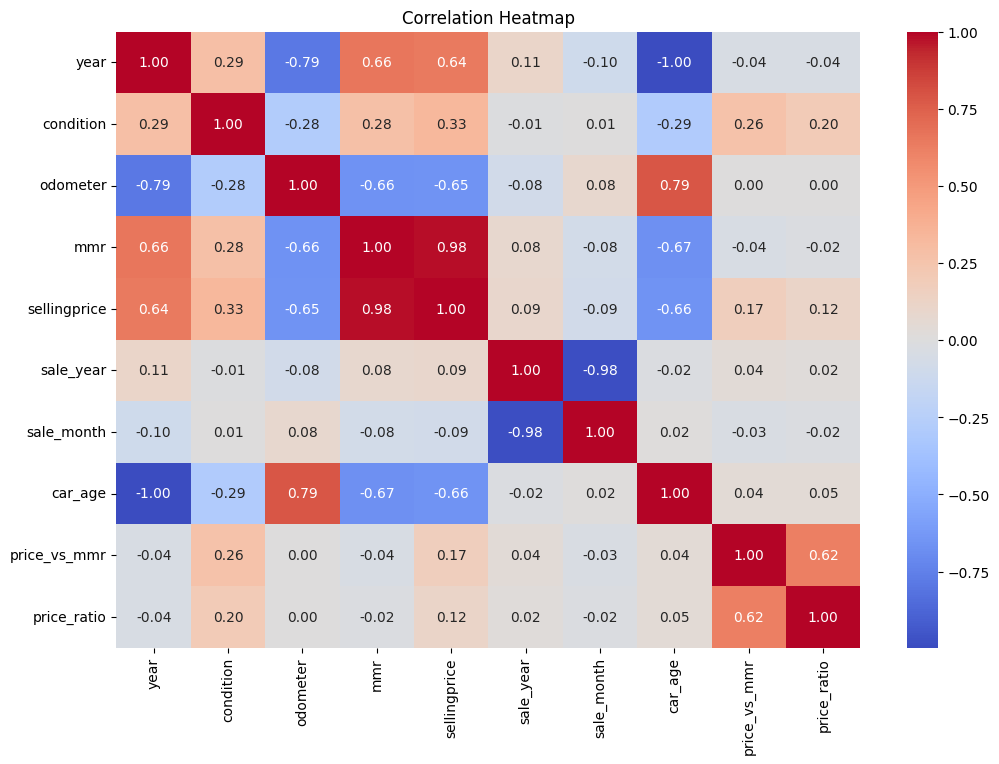

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

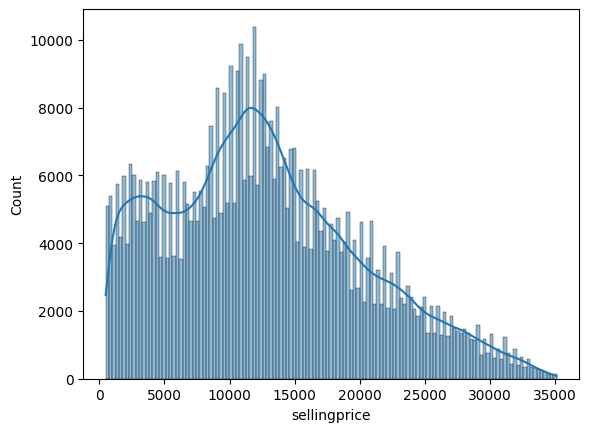

In [27]:
sns.histplot(df['sellingprice'],kde=True)
plt.show()

<Axes: xlabel='mmr', ylabel='Count'>

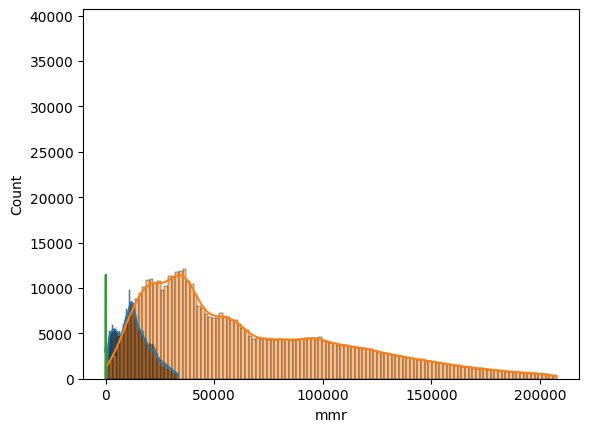

In [28]:
sns.histplot(df['mmr'],kde=True)
sns.histplot(df['odometer'],kde=True)
sns.histplot(df['condition'],kde=True)

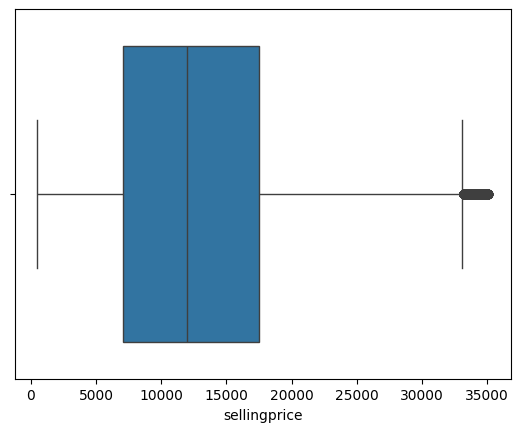

In [29]:
sns.boxplot(x=df['sellingprice'])
plt.show()

<Axes: xlabel='odometer'>

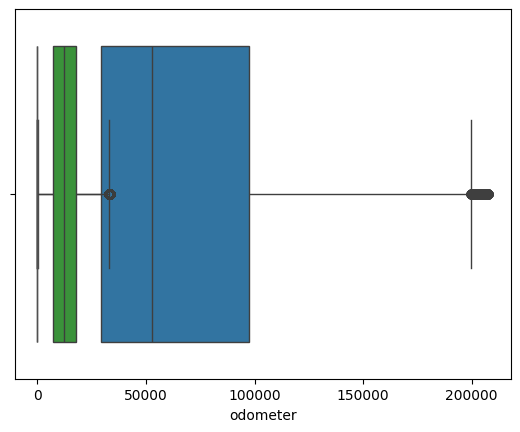

In [30]:
sns.boxplot(x=df['odometer'])
sns.boxplot(x=df['condition'])
sns.boxplot(x=df['mmr'])

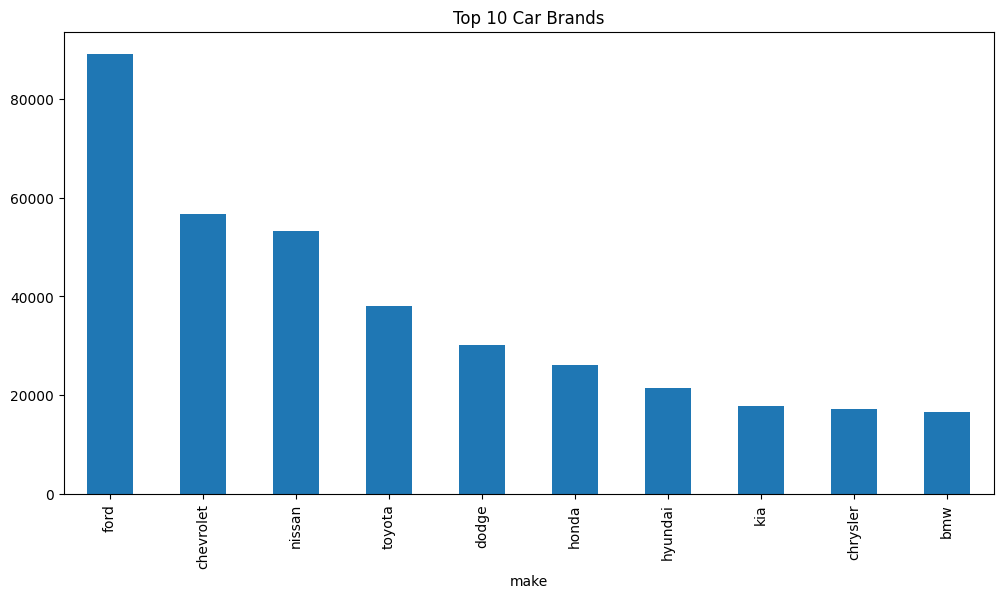

In [31]:
plt.figure(figsize=(12,6))
df['make'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Car Brands")
plt.show()

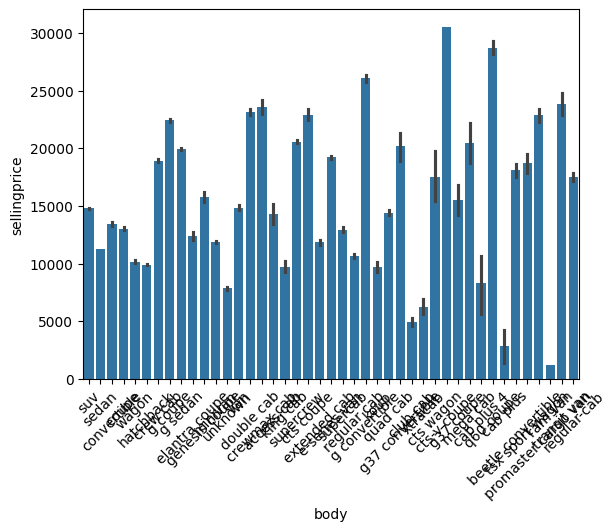

In [32]:
sns.barplot(data=df,x='body',y='sellingprice',estimator=np.mean)
plt.xticks(rotation=45)
plt.show()

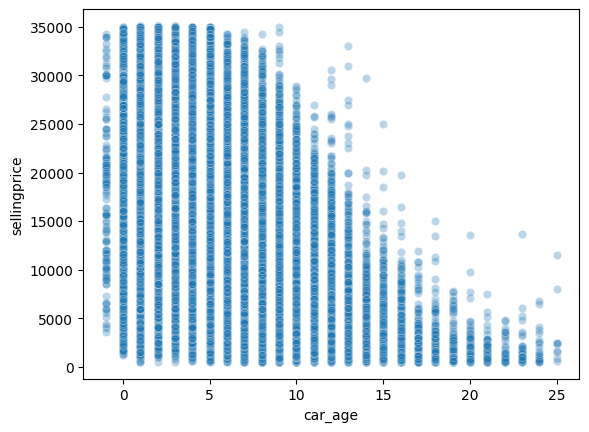

In [33]:
sns.scatterplot(data=df,x='car_age',y='sellingprice',alpha=0.3)
plt.show()

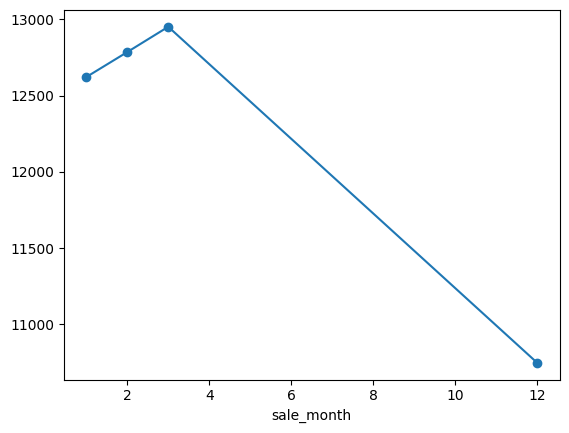

In [34]:
monthly=df.groupby('sale_month')['sellingprice'].mean()
monthly.plot(marker='o')
plt.show()

In [35]:
df.groupby('make')['sellingprice'].mean().sort_values(ascending=False)

make
maserati         22268.750000
ram              22165.979498
infiniti         19546.247256
lexus            18582.374560
land rover       18391.388029
mercedes-benz    17628.645626
bmw              16379.196341
lincoln          16370.284575
gmc              15861.640439
audi             15433.977249
subaru           15406.209748
porsche          15210.445205
hummer           14933.936061
vw               14825.000000
jeep             14269.010337
ford             14126.644398
acura            13993.536258
mercedes-b       13650.000000
cadillac         13087.345826
toyota           12351.341873
mini             12319.847921
jaguar           12035.480859
volvo            11900.592511
kia              11809.127889
nissan           11767.549031
landrover        11516.666667
honda            11335.215582
chrysler         11272.484422
chevrolet        11215.670933
dodge            11192.658603
hyundai          10971.456655
buick            10906.162623
fiat             10367.487861
mazda

In [36]:
df.groupby('state')['sellingprice'].mean().sort_values(ascending=False)

state
on    17102.950661
tn    16080.718737
co    14883.275853
pa    14736.389631
mi    14367.528887
il    14250.125689
mo    13829.256246
nv    13713.592328
wa    13668.139732
mn    13340.899583
qc    13060.145548
fl    12981.048588
wi    12852.219998
oh    12847.342950
ca    12831.754661
nj    12594.468437
tx    12429.399133
ne    12398.430493
ga    12144.249737
hi    12062.884456
ut    11822.024232
ny    11340.736270
or    11319.327539
az    11144.996405
ms    11001.061972
ab    10796.004994
in    10780.245589
la    10430.758738
sc    10273.294482
ns    10213.114754
pr     9582.256214
al     9440.000000
va     8870.513664
nc     8781.873600
md     7807.555457
nm     7380.451128
ok     7149.253731
ma     6942.517088
Name: sellingprice, dtype: float64

In [37]:
df.groupby('body')['sellingprice'].mean().sort_values(ascending=False)

body
cts-v coupe            30500.000000
q60 coupe              28680.000000
g convertible          26062.460568
transit van            23823.684211
crewmax cab            23564.691943
double cab             23125.001276
cts coupe              22901.910828
promaster cargo van    22840.677966
g coupe                22423.743719
supercrew              20580.988026
mega cab               20466.393443
g37 convertible        20177.500000
g sedan                19939.968447
e-series van           19205.690608
crew cab               18910.672460
tsx sport wagon        18691.666667
beetle convertible     18114.406780
cts wagon              17521.428571
regular-cab            17466.666667
genesis coupe          15762.244898
g37 coupe              15529.166667
van                    14834.639300
suv                    14811.492478
quad cab               14428.742025
access cab             14268.933824
convertible            13421.827662
coupe                  13040.759478
supercab               